In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice

In [3]:
data_folder = '/Volumes/ogma/human_octagon/RAW/standard'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=404)

filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-53-56_JL13_SecondSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-23-50_JL13_FirstSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-53-34_YW13_SecondSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-23-37_YW13_FirstSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocess

In [5]:
trial_lists_solo_cmb = [trial_lists_solo[i] + trial_lists_solo[i+1] for i in range(0, len(trial_lists_solo), 2)]

In [7]:
dropped_trials = 5

In [8]:
trial_lists_solo_cmb = [trial_list[dropped_trials:] for trial_list in trial_lists_solo_cmb]

In [10]:
json_filenames_social, _ = identify_filepaths.get_filenames(data_folder)
_, trial_lists_social = prepare_data.prepare_data(data_folder, json_filenames_social, combine=False)

IntProgress(value=0, max=101)

filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-31-00_YW13_JL13_Social.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240927_1/2024-09-27_14-25-20_SH27_EN27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241017_1/2024-10-17_14-28-40_SP17_AW17_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241017_2/2024-10-17_16-41-38_ZH17_EM17_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241112_1/2024-11-12_13-31-14_KA12_WM12_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241112_2/2024-11-12_15-23-24_FA12_SL12_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/h

In [12]:
trial_lists_social_cropped = [trial_list[dropped_trials:] for trial_list in trial_lists_social]

In [13]:
len(trial_lists_social_cropped)

101

## Location heatmap

In [14]:
from analysis import opponent_visibility

In [15]:
def collect_slice_onset_radii(trial_lists, player_id=0):
    """Collect radial distances at slice onset across trial lists."""

    radii = []

    for trial_list in trial_lists:
        for trial_index in range(1, len(trial_list)):
            pos = opponent_visibility.get_player_position_slice_onset(
                player_id=player_id,
                trial=None,
                trial_list=trial_list,
                trial_index=trial_index
            )

            if pos is None:
                continue

            x_val, y_val = pos
            r = np.sqrt(x_val**2 + y_val**2)
            radii.append(r)

    return np.asarray(radii)

In [16]:
num_rings = 10
arena_radius = 19.74449542008289

radial_bins = np.linspace(0, arena_radius, num_rings + 1)

In [23]:
from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib import cm
import matplotlib.pyplot as plt

In [79]:
def plot_slice_onset_ring_counts(
    ring_counts,
    radial_bins,
    cmap_name="inferno",
    show_counts=True,
    title="Slice-onset position counts"
):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=0,
        vmax=np.nanmax(ring_counts)
    )

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor="none",
        edgecolor="none",
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        count = ring_counts[i]

        patch = Polygon(
            vertices,
            facecolor=cmap(norm(count)),
            edgecolor="none",
            linewidth=0.001,
            antialiased=True
        )

        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        if show_counts:
            ax.text(
                0,
                r_mid,
                str(int(count)),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                fontweight="bold"
            )

    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor="black",
        facecolor="none",
        lw=2
    )
    ax.add_patch(octagon_patch)

    ax.set_title(title, fontsize=18)
    ax.set_xlim([-arena_radius, arena_radius])
    ax.set_ylim([-arena_radius, arena_radius])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.75)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    #cbar.set_ticks(np.arange(0, 3501, 1000))
    cbar.set_label("slice-onset count", fontsize=20)

    return fig, ax

### solo trials

In [47]:
radii = collect_slice_onset_radii(
    trial_lists_solo_cmb,
    player_id=0
)

ring_counts, _ = np.histogram(radii, bins=radial_bins)

print(ring_counts)

[2098 3559 3058 2309 1628 1201  987 1377 2557 2291]


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/141799653.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

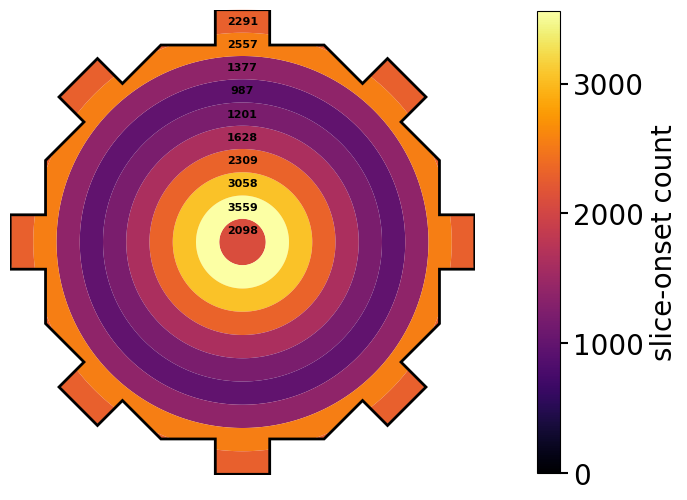

In [74]:
plot_slice_onset_ring_counts(
    ring_counts,
    radial_bins,
    title=""
)

In [75]:
ring_proportions_solo = ring_counts / np.sum(ring_counts)

In [80]:
ring_proportions_solo

array([0.09959649, 0.16895324, 0.14516971, 0.1096131 , 0.0772846 ,
       0.057014  , 0.04685497, 0.0653691 , 0.12138619, 0.1087586 ])

In [101]:
def plot_slice_onset_ring_proportions(
    ring_proportions,
    radial_bins,
    cmap_name="inferno",
    show_values=True,
    title="Slice-onset position proportions"
):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(ring_proportions))

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor="none",
        edgecolor="none",
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        prop = ring_proportions[i]

        patch = Polygon(
            vertices,
            facecolor=cmap(norm(prop)),
            edgecolor="none",
            linewidth=0,
            antialiased=True
        )
        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        if show_values:
            ax.text(
                0,
                r_mid,
                f"{prop:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black",
                fontweight="bold"
            )

    # optional ring outlines without seam
    for r in radial_bins[1:-1]:
        circle = plt.Circle(
            (0, 0),
            r,
            edgecolor="black",
            facecolor="none",
            linewidth=0.4
        )
        circle.set_clip_path(octagon_clip)
        ax.add_patch(circle)

    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor="black",
        facecolor="none",
        lw=2
    )
    ax.add_patch(octagon_patch)

    ax.set_title(title, fontsize=18)
    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.005, shrink=0.7)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    cbar.set_ticks(np.arange(0, 0.16, 0.05))
    cbar.set_label("proportion of slice onset positions", fontsize=20)

    return fig, ax

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/22926533.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

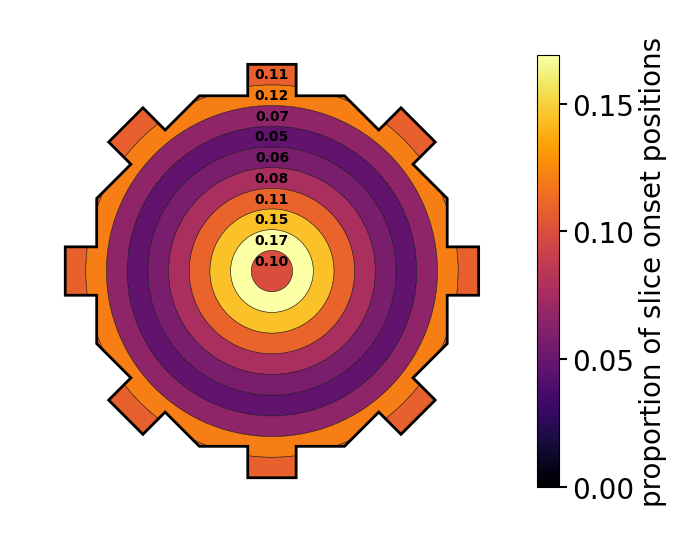

In [102]:
plot_slice_onset_ring_proportions(
    ring_proportions_solo,
    radial_bins,
    title=""
)

### social trials

In [49]:
radii_social = []
for player_id in range(2):
    radii = collect_slice_onset_radii(
        trial_lists_social_cropped,
        player_id=player_id
    )
    radii_social =+ radii


ring_counts_social, _ = np.histogram(radii_social, bins=radial_bins)

print(ring_counts_social)

[1134 1996 1768 1347  949  808  776 1071 1603 1261]


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/2066900720.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

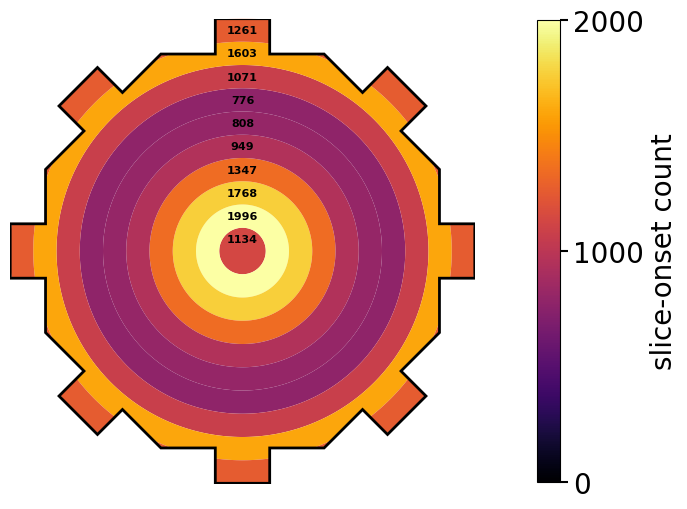

In [72]:
plot_slice_onset_ring_counts(
    ring_counts_social,
    radial_bins,
    title=""
)

In [103]:
ring_proportions_social = ring_counts_social / np.sum(ring_counts_social)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/22926533.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

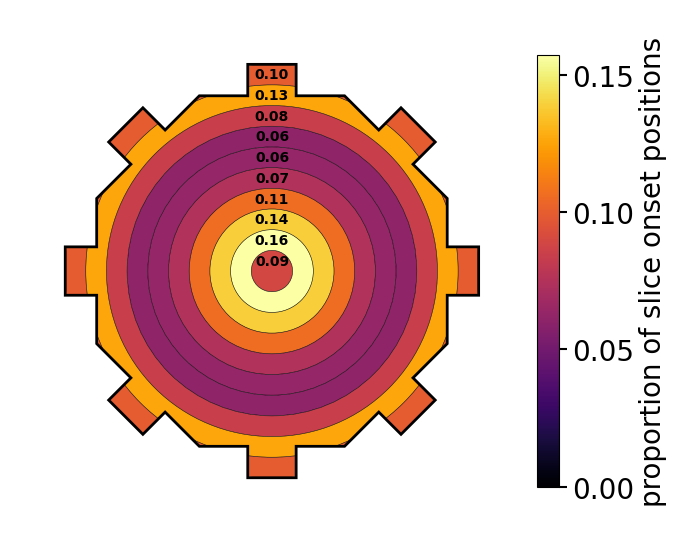

In [104]:
plot_slice_onset_ring_proportions(
    ring_proportions_social,
    radial_bins,
    title=""
)

### P(high) in solo across walls

In [106]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    for session_id in np.arange(len(trial_lists_solo_cmb))
}

In [107]:
for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    trial_list = trial_lists_solo_cmb[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 64


Processing session: 1


Number of trials in full session: 61


Processing session: 2


Number of trials in full session: 64


Processing session: 3


Number of trials in full session: 67


Processing session: 4


Number of trials in full session: 64


Processing session: 5


Number of trials in full session: 52


Processing session: 6


Number of trials in full session: 86


Processing session: 7


Number of trials in full session: 75


Processing session: 8


Number of trials in full session: 68


Processing session: 9


Number of trials in full session: 56


Processing session: 10


Number of trials in full session: 97


Processing session: 11


Number of trials in full session: 90


Processing session: 12


Number of trials in full session: 61


Processing session: 13


Number of trials in full session: 53


Processing session: 14


Number of trials in full session: 53


Processing session: 15


Number of trials in ful

In [108]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']
    print(session_id)

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201


In [109]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

In [110]:
wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']
 for session_id in analysis_results
 ]
chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']
 for session_id in analysis_results
 ]


wall_numbers = np.concatenate(wall_number_list).astype(int)
chose_high = np.concatenate(chose_high_list)

In [111]:
# more efficient code with vectorised functions

wall_probabilities = np.full(8, np.nan)

# specify min bins == highest integer value + 1
# slice from index 1 because 0 will always be counted, but is not relevant
counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

mask = counts > 0  # Avoid division by zero
wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

In [112]:
# get error bars

standard_error = np.sqrt((wall_probabilities * (1 - wall_probabilities)) / len(wall_number_list))

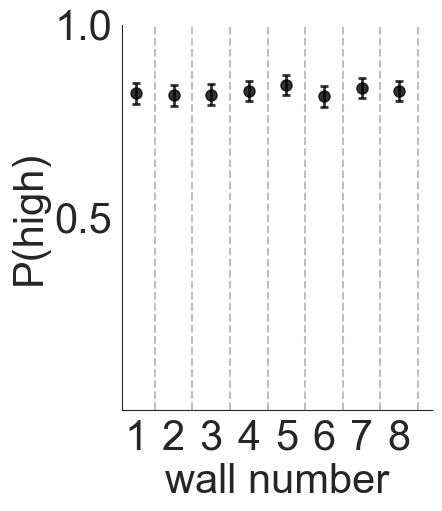

In [176]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(4, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
#sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="black")
#plt.errorbar(x=wall_numbers, y=wall_probabilities, yerr=standard_error, fmt="o")
plt.errorbar(
    wall_numbers,
    wall_probabilities,
    yerr=standard_error,
    fmt='o',
    alpha=0.8,
    color="black",
    markersize=8,

    ecolor='black',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)
# Customize labels and title
plt.xlabel("wall number", fontsize=30)
plt.ylabel("P(high)", fontsize=30)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers, fontsize=30)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=30)

ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

### P(high) in solo vs social

In [174]:
import plotting.plot_probability_chose_wall as plot_probability_chose_wall
import plotting.plot_violinplots as plot_violinplots

In [127]:
(probability_choose_high_social_array,
probability_choose_high_solo_array, _, _) = plot_probability_chose_wall.get_probability_chose_high_solo_social_all_sessions_df(
                                            trial_lists_solo_cmb, trial_lists_social_cropped,
                                            wall_sep=None, trial_type=globals.HIGH_LOW, cut_solo_trials=10)

In [130]:
palette=sns.color_palette("autumn")

In [133]:
palette=["firebrick","salmon"]

In [177]:
def plot_violinplot(data_list, label_list, ylabel, xlabel="",
                ylim=(0.0,1), figsize=(10, 8), set_aspect=3, fontsize=32, custom_colors=None, color_offset=0, 
                return_data=False, inner='box', split=False, bw_adjust=1.0):
    ''' 
    Helper function to create violin plots for multiple datasets with optional return values.
    
    Parameters:
    -----------
    data_list : list of arrays
        List containing arrays of data to plot
    label_list : list of strings
        List containing labels for each dataset
    ylabel : str
        Label for y-axis
    xlabel : str
        Label for x-axis (optional)
    ylim : tuple
        Y-axis limits (default: (0.0, 1))
    set_aspect : float
        Aspect ratio (default: 3)
    fontsize : int
        Font size for labels (default: 24)
    custom_colors : list or None
        Optional list of colors to use. If None, uses Paired palette.
    color_offset : int
        Offset to start color selection from the palette (default: 0)
    return_data : bool
        Whether to return the axes, dataframe and data_list (default: False)
    inner : {'box', 'quartile', 'point', 'stick', None}
        Representation of the datapoints in the violin interior (default: 'box')
    split : bool
        Whether to split the violins when there are only two categories (default: False)
    bw_adjust : float
        Adjusts the bandwidth of the kernel density estimation (default: 1.0)
        Higher values create smoother plots, lower values show more detail
    '''
    
    if len(data_list) != len(label_list):
        raise ValueError("The number of datasets must match the number of labels")
    
    # Prepare data
    all_data = []
    all_labels = []
    
    # create labels for each dataset based on the ravelled size of the data
    # ravel to flatten arrays to adapt to arbitrary original shapes
    for data, label in zip(data_list, label_list):
        all_data.append(data.ravel())
        all_labels.append(np.full(data.ravel().size, label))
    
    # Concatenate all data and labels
    data = np.concatenate(all_data)
    labels = np.concatenate(all_labels)

    # Create DataFrame for Seaborn
    df = pd.DataFrame({
        "Probability": data,
        "Condition": labels
    })
    
    # Create color palette
    if custom_colors is None:
        paired = sns.color_palette("Paired")
        # Use as many colors as needed from the palette
        # using modulo here so that if there are more datasets than colours (12), 
        # it will wrap around and return to the beginning
        # Added color_offset to start from a specific position in the palette
        custom_palette = [paired[(i + color_offset) % len(paired)] for i in range(len(data_list))]
    else:
        # Use provided colors
        custom_palette = custom_colors

    # Create figure with larger size for poster visibility
    plt.figure(figsize=figsize)
    
    # Create violinplot with custom properties
    ax = sns.violinplot(x="Condition", y="Probability", data=df, palette=custom_palette, 
                     inner=inner, split=split, bw_adjust=bw_adjust, width=0.8)
    
    # Increase linewidth for better visibility
    for violin in ax.collections:
        violin.set_edgecolor('black')
        violin.set_linewidth(2)
    
    # Format plot with increased font sizes for poster visibility
    plt.ylabel(ylabel, fontsize=fontsize)
    plt.xlabel(xlabel, fontsize=fontsize)
    plt.xticks(fontsize=fontsize)  # Larger font for x-tick labels
    plt.yticks(np.arange(0,1.1,0.5),fontsize=fontsize)  # Larger font for y-tick labels
    plt.ylim(ylim)  # Set y-axis limits for probabilities
    # plt.gca().set_aspect(set_aspect)
    plt.tight_layout()

    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if return_data:
        return ax, df, data_list
    else:
        return ax 

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/3694905814.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x="Condition", y="Probability", data=df, palette=custom_palette,


<Axes: ylabel='P(high)'>

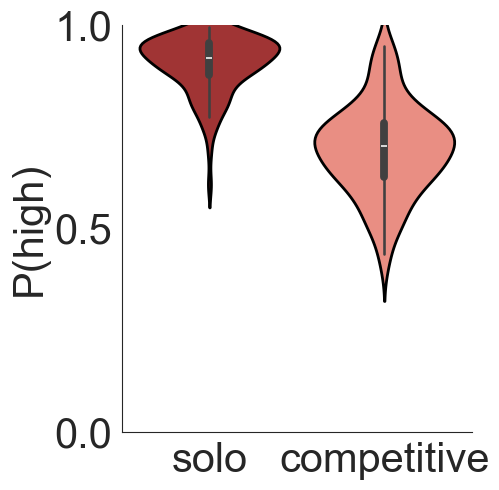

In [180]:
data = [probability_choose_high_solo_array, probability_choose_high_social_array]
labels = ['solo', 'competitive']
plot_violinplot(data, labels, 'P(high)', ylim=[0.0,1], figsize=(5, 5), color_offset=0,
                                 fontsize=30, custom_colors=palette)

### First-seen ring plots

#### P(high | high first visible) solo

In [135]:
num_players = 1
first_visible_wall_index = 0
chosen_wall_index = 0

In [136]:
(trial_list_high_vis_filtered_1,
 trial_list_high_vis_and_choice_filtered_1) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    trial_lists_solo_cmb,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0.
 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0.]
And the number of valid trials at this step is 21
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 1.]
And the number of valid trials at this step is 19
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1.
 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 0. 1. 0.]
And the number of valid trials at this step is 20
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 0. 

#### P(high | low first visible) solo

In [137]:
num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 0

In [138]:
(trial_list_high_vis_filtered_2,
 trial_list_high_vis_and_choice_filtered_2) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    trial_lists_solo_cmb,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 0.]
And the number of valid trials at this step is 24
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1.
 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 1. 0. 0.]
And the number of valid trials at this step is 24
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1.
 0. 1. 0. 0. 0.]
And the number of valid trials at this step is 25
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 1. 

#### difference

#### P(high | high first visible) social

In [153]:
num_players = 2
first_visible_wall_index = 0
chosen_wall_index = 0

In [154]:
(trial_list_high_vis_filtered_3,
 trial_list_high_vis_and_choice_filtered_3) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    trial_lists_social_cropped,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

proportion loser's choice confident = 0.26804123711340205
proportion loser's choice confident = 0.26804123711340205
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1.
 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1.
 1. 1. 1.]
And the number of valid trials at this step is 24
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1.]
And the number of valid trials at this step is 36
proportion loser's choice confident = 0.5
proportion loser's choice confident = 0.3333333333333333


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:149: RuntimeWarning: Mean of empty slice
  highest_alignment_val = np.max(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid va

proportion loser's choice confident = 0.17333333333333334


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:149: RuntimeWarning: Mean of empty slice
  highest_alignment_val = np.max(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid va

proportion loser's choice confident = 0.17333333333333334
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0.
 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0.]
And the number of valid trials at this step is 10
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1.
 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0.]
And the number of valid trials at this step is 17
proportion loser's choice confident = 0.3
proportion loser's choice confident = 0.058823529411764705


...

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis

proportion loser's choice confident = 0.2087912087912088


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis

proportion loser's choice confident = 0.2087912087912088
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1.
 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
And the number of valid trials at this step is 25
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
And the number of valid trials at this step is 14
proportion loser's choice confident = 0.44
proportion loser's choice confident = 0.42857142857142855


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

#### P(high | low first visible) social

In [155]:
num_players = 2
first_visible_wall_index = 1
chosen_wall_index = 0

In [156]:
(trial_list_high_vis_filtered_4,
 trial_list_high_vis_and_choice_filtered_4) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    trial_lists_social_cropped,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

proportion loser's choice confident = 0.26804123711340205
proportion loser's choice confident = 0.26804123711340205
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 0.]
And the number of valid trials at this step is 18
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0.]
And the number of valid trials at this step is 26
proportion loser's choice confident = 0.6111111111111112
proportion loser's choice confident = 0.2692307692307692


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:149: RuntimeWarning: Mean of empty slice
  highest_alignment_val = np.max(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid va

proportion loser's choice confident = 0.17333333333333334
proportion loser's choice confident = 0.17333333333333334


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:149: RuntimeWarning: Mean of empty slice
  highest_alignment_val = np.max(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid va

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1.
 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0.]
And the number of valid trials at this step is 12
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 1. 0. 0.]
And the number of valid trials at this step is 20
proportion loser's choice confident = 0.3333333333333333
proportion loser's choice confident = 0.35


...

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis

proportion loser's choice confident = 0.2087912087912088


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/analysis/loser_inferred_choice.py:47: RuntimeWarning: Mean of empty slice
  return np.argmax(np.nanmean(cosine_similarity_trajectory, axis=1))
/Users/benny/Repos/octagon_analysis/analysis

proportion loser's choice confident = 0.2087912087912088
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
And the number of valid trials at this step is 19
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 1.]
And the number of valid trials at this step is 17
proportion loser's choice confident = 0.15789473684210525
proportion loser's choice confident = 0.29411764705882354


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

#### calculate probabilities

In [157]:
num_radial_bins = 10
r_max = arena_radius
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

In [139]:
solo_filtered = [
    trial_list_high_vis_filtered_1,
    trial_list_high_vis_filtered_2
]

solo_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_1,
    trial_list_high_vis_and_choice_filtered_2
]

In [158]:
social_filtered = [
    trial_list_high_vis_filtered_3,
    trial_list_high_vis_filtered_4
]

social_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_3,
    trial_list_high_vis_and_choice_filtered_4
]

In [140]:
num_players = 1

In [144]:
bins_wall_seen_solo = []
bins_wall_seen_wall_chosen_solo = []

for group_index, (filtered, filtered_and_choice) in enumerate(
    zip(solo_filtered, solo_filtered_and_choice),
    start=1
):
    # initialise bin counts for this quartile group
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        # denominator: trials where player saw specified first-seen wall
        trial_lists_denominator = filtered[player_id]

        # numerator: trials where player additionally chose specified chosen wall
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for group {group_index}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen_solo.append(wall_seen_counts)
    bins_wall_seen_wall_chosen_solo.append(wall_seen_wall_chosen_counts)

Done for group 1, player 0, counts in numerator bin 0: 645.0
Done for group 2, player 0, counts in numerator bin 0: 603.0


In [159]:
num_players = 2

In [161]:

bins_wall_seen_social = []
bins_wall_seen_wall_chosen_social = []

for group_index, (filtered, filtered_and_choice) in enumerate(
    zip(social_filtered, social_filtered_and_choice),
    start=1
):
    # initialise bin counts for this quartile group
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        # denominator: trials where player saw specified first-seen wall
        trial_lists_denominator = filtered[player_id]

        # numerator: trials where player additionally chose specified chosen wall
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for group {group_index}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen_social.append(wall_seen_counts)
    bins_wall_seen_wall_chosen_social.append(wall_seen_wall_chosen_counts)

Done for group 1, player 0, counts in numerator bin 0: 236.0
Done for group 1, player 1, counts in numerator bin 0: 448.0
Done for group 2, player 0, counts in numerator bin 0: 125.0
Done for group 2, player 1, counts in numerator bin 0: 237.0


In [145]:
pH_by_bin_solo = []
probabilities_solo = []

min_trials_per_bin = 15

for group_index, (numerator_counts, denominator_counts) in enumerate(
    zip(bins_wall_seen_wall_chosen_solo, bins_wall_seen_solo),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    # filter out bins with too few denominator trials
    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_solo.append(pH_by_bin)
    probabilities_solo.append(pH_by_bin)

    print(f"Computed probabilities for group {group_index}")

Computed probabilities for group 1
Computed probabilities for group 2


In [162]:
pH_by_bin_social = []
probabilities_social = []

min_trials_per_bin = 15

for group_index, (numerator_counts, denominator_counts) in enumerate(
    zip(bins_wall_seen_wall_chosen_social, bins_wall_seen_social),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    # filter out bins with too few denominator trials
    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_social.append(pH_by_bin)
    probabilities_social.append(pH_by_bin)

    print(f"Computed probabilities for group {group_index}")

Computed probabilities for group 1
Computed probabilities for group 2


In [181]:
def plot_heatmap_phigh_circular(
    probabilities,
    radial_bins,
    bin_counts=None,
    cmap_name='seismic',
    diff_cmap_name='PiYG',
    show_counts=True,
    title=None,
    diff=False
):
    '''Plot P(Choose High) across radial bins overlaid on octagon.

    probabilities: 1D array of probabilities across radial bins
    radial_bins: bin edges for radial distance
    bin_counts: 1D array of denominator counts for each radial bin
    '''

    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    
    if diff:
        norm = mpl.colors.Normalize(vmin=-1, vmax=1)
    else:
        norm = mpl.colors.Normalize(vmin=0, vmax=1)

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        color = cmap(norm(probabilities[i]))

        patch = Polygon(
            vertices,
            facecolor=color,
            edgecolor='black',
            linewidth=0,
            antialiased=True
        )

        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        # Add bin count label inside ring
        if show_counts and bin_counts is not None:
            count = bin_counts[i]

            if not np.isnan(probabilities[i]):
                
                ax.text(
                    0,
                    r_mid,
                    f"{int(count)}",
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='white',
                    fontweight='bold'
                )

    # Overlay octagon outline
    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor='black',
        facecolor='none',
        lw=2
    )
    ax.add_patch(octagon_patch)

    if title is not None:
        if diff:
            ax.set_title(f"average ΔP(high) = {title}", fontsize=20)
        else:
            ax.set_title(f"average P(high) = {title}", fontsize=20)

    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0, shrink=1)
    cbar.ax.tick_params(labelsize=30, length=6, width=1.5)
    if diff:
        cbar.set_label("ΔP(high)", size=30)
        cbar.set_ticks(np.arange(-1, 1.1, 0.5))
    else:
        cbar.set_label("P(high)", size=30)
        cbar.set_ticks(np.arange(0, 1.1, 0.5))

    return fig, ax

### Solo P(high | high first visible)

In [147]:
title1=np.round(np.nanmean(probabilities_solo[0]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/222695969.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.97'}>)

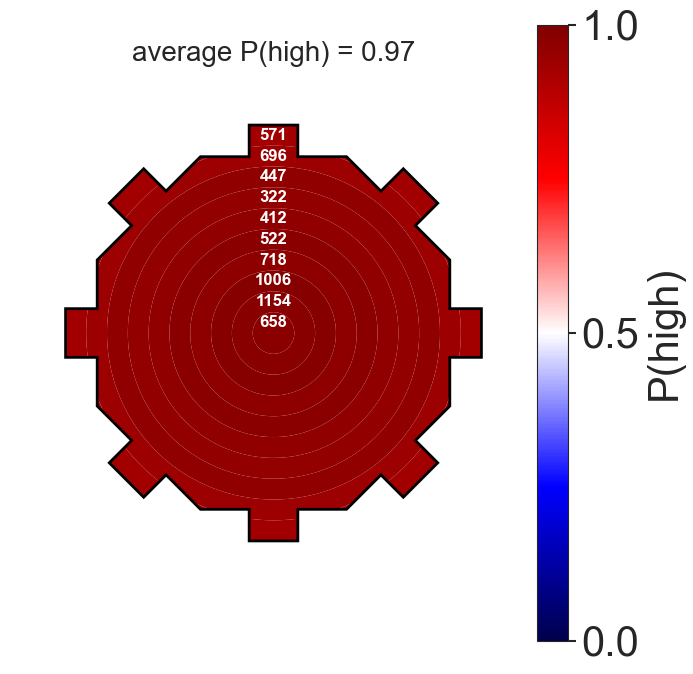

In [182]:
plot_heatmap_phigh_circular(probabilities_solo[0], radial_bins, bin_counts=bins_wall_seen_solo[0],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title1)

### Solo P(high | low first visible)

In [149]:
title2=np.round(np.nanmean(probabilities_solo[1]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/182069974.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.83'}>)

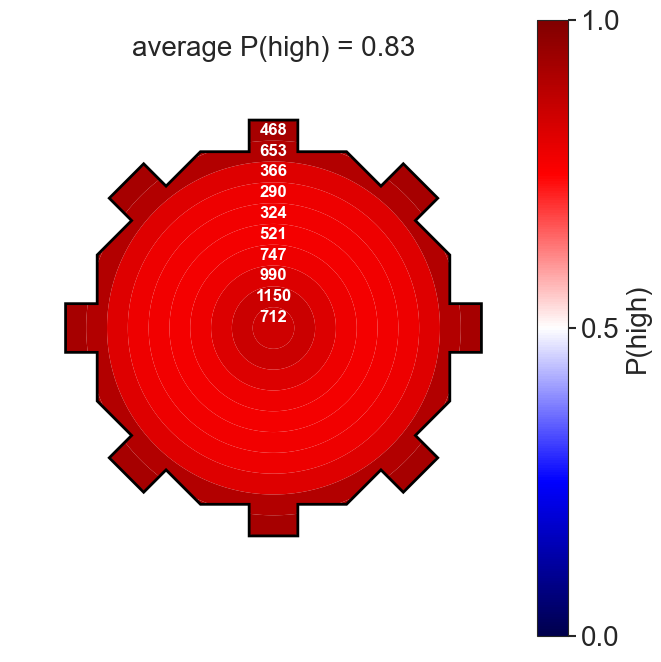

In [163]:
plot_heatmap_phigh_circular(probabilities_solo[1], radial_bins, bin_counts=bins_wall_seen_solo[1],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title2)

### Social P(high | high first visible)

In [164]:
title3=np.round(np.nanmean(probabilities_social[0]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/182069974.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.73'}>)

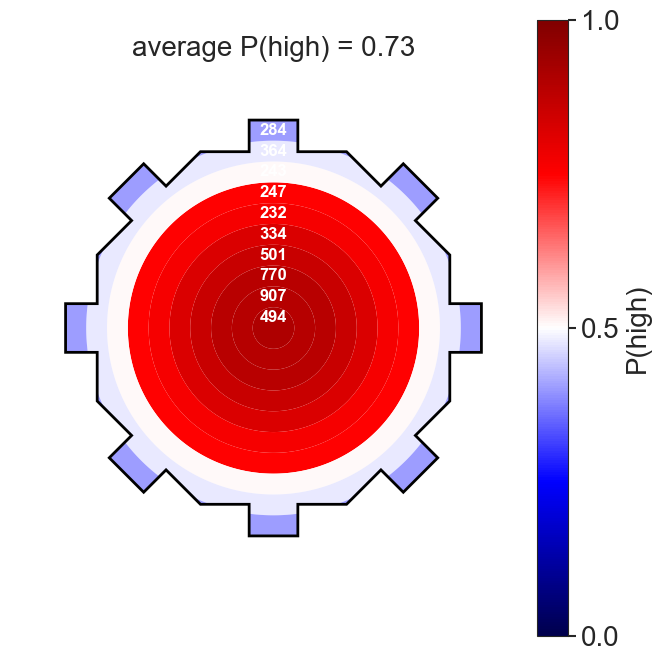

In [165]:
plot_heatmap_phigh_circular(probabilities_social[0], radial_bins, bin_counts=bins_wall_seen_social[0],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title3)

### Social P(low | high first visible)

In [166]:
title4=np.round(np.nanmean(probabilities_social[1]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/182069974.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.55'}>)

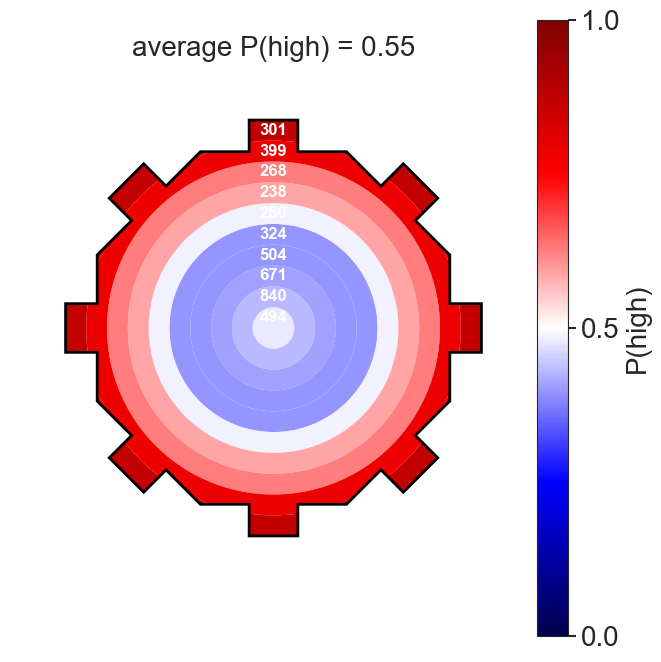

In [167]:
plot_heatmap_phigh_circular(probabilities_social[1], radial_bins, bin_counts=bins_wall_seen_social[1],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title4)

#### difference

In [151]:
diff_solo = probabilities_solo[0] - probabilities_solo[1]

In [168]:
diff_social = probabilities_social[0] - probabilities_social[1]

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/222695969.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.14'}>)

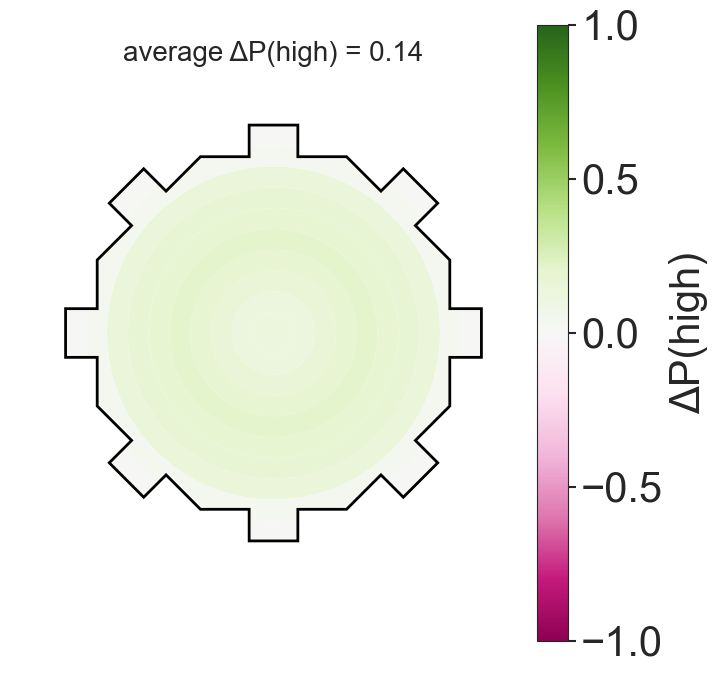

In [183]:
plot_heatmap_phigh_circular(diff_solo, radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(diff_solo),2), diff=True)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_14792/182069974.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.18'}>)

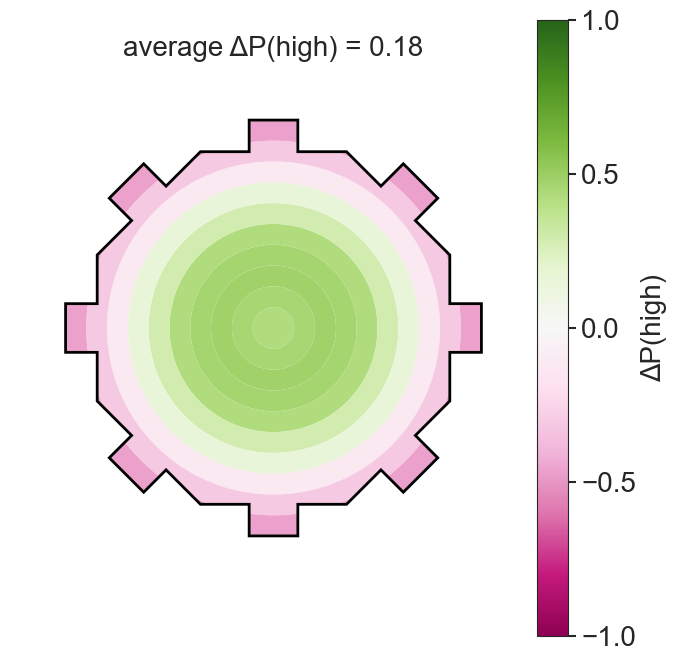

In [169]:
plot_heatmap_phigh_circular(diff_social, radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(diff_social),2), diff=True)

### P(low | low first seen) solo vs social and across wall separations

In [241]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'drop_first_1': None,
                'wall_sep_1': None,
                'wall_sep_2': None,
                'wall_sep_4': None
            }
        }
    for session_id in np.arange(len(trial_lists_solo_cmb))
    #for session_id in np.arange(len(trial_lists_social_cropped))
}

In [242]:
for session_id in analysis_results.keys():

    player_data = analysis_results[session_id]
    trial_list = trial_lists_solo_cmb[session_id]
    #trial_list = trial_lists_social_cropped[session_id]
    
    player_data['trial_lists']['drop_first_1'] = trial_list

    player_data['trial_lists']['wall_sep_1'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=1)]
    player_data['trial_lists']['wall_sep_2'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=2)]
    player_data['trial_lists']['wall_sep_4'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=4)]

In [243]:
trial_lists_sep1 = []
trial_lists_sep2 = []
trial_lists_sep4 = []

for session_id in range(len(trial_lists_solo_cmb)):
#for session_id in range(len(trial_lists_social_cropped)):
    
    player_data = analysis_results[session_id]
    trial_lists_sep1.append(player_data['trial_lists']['wall_sep_1'])
    trial_lists_sep2.append(player_data['trial_lists']['wall_sep_2'])
    trial_lists_sep4.append(player_data['trial_lists']['wall_sep_4'])

In [244]:
num_players = 1
#num_players = 2
first_visible_wall_index = 1
chosen_wall_index = 1

In [245]:
(trial_list_low_vis_filtered_1,
  trial_list_low_vis_and_choice_filtered_1) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(trial_lists_sep1,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]
And the number of valid trials at this step is 5
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
And the number of valid trials at this step is 5
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0.]
And the number of valid trials at this step is 8
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0.]
And the number of valid trials at this step is 5
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0.]
And the number of valid trials at this step is 5
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_s

In [246]:
(trial_list_low_vis_filtered_2,
  trial_list_low_vis_and_choice_filtered_2) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(trial_lists_sep2,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0.]
And the number of valid trials at this step is 10
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.]
And the number of valid trials at this step is 5
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0.]
And the number of valid trials at this step is 9
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1.]
And the number of valid trials at this step is 11
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0.]
And the number of valid trials at this step is 8
filter_trials_one_wall_becomes_visible

In [247]:
(trial_list_low_vis_filtered_4,
  trial_list_low_vis_and_choice_filtered_4) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(trial_lists_sep4,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1.]
And the number of valid trials at this step is 9
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0.]
And the number of valid trials at this step is 14
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0.]
And the number of valid trials at this step is 8
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
And the number of valid trials at this step is 4
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
And the number of valid trials at this step is 8
filter_trials_one_wall_becomes_visible_

In [248]:
p1 = []
p2 = []
p4 = []

for session_id in range(len(trial_lists_sep1)):
    probability_1 = len(trial_list_low_vis_and_choice_filtered_1[0][session_id])/len(trial_lists_sep1[session_id])
    probability_2 = len(trial_list_low_vis_and_choice_filtered_2[0][session_id])/len(trial_lists_sep2[session_id])
    probability_4 = len(trial_list_low_vis_and_choice_filtered_4[0][session_id])/len(trial_lists_sep4[session_id])

    p1.append(probability_1)
    p2.append(probability_2)
    p4.append(probability_4)

In [249]:
data = [
    p1,
    p2,
    p4
]

In [213]:
from scipy.stats import mannwhitneyu, kruskal

In [251]:
# overall
stat, p = kruskal(p1,p2,p4)
print("Kruskal-Wallis p =", p)

# pairwise
p_12 = mannwhitneyu(p1,p2).pvalue
p_24 = mannwhitneyu(p2,p4).pvalue
p_14 = mannwhitneyu(p1,p4).pvalue

print(p_12,p_24,p_14)

Kruskal-Wallis p = 5.0143185815705166e-21
1.2081943351214155e-13 0.014487329784357988 2.463673896429994e-19


## Solo P(Low | Low first seen) by wall separation

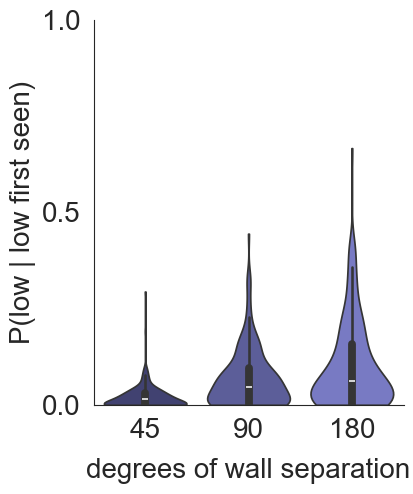

In [252]:
palette = sns.color_palette("tab20b", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)
    
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['45', '90', '180'], fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("degrees of wall separation", fontsize=20, labelpad=10)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

## Social P(Low | Low first seen) by wall separation

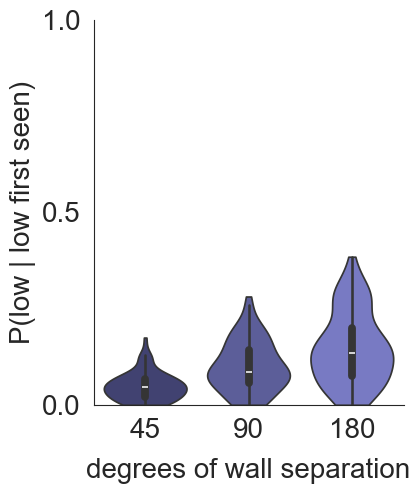

In [239]:
palette = sns.color_palette("tab20b", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)
    
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['45', '90', '180'], fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("degrees of wall separation", fontsize=20, labelpad=10)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()